# CRAG Implementation: Clustering for Data Reduction
## CSCI 4380 - Data Mining Final Project

**Research Paper:** [Clustered Retrieved Augmented Generation (CRAG)](https://arxiv.org/html/2406.00029v1)  
**Published:** May 24, 2024  
**Dataset:** Amazon Unlocked Mobile Reviews (413,841 entries)

---

### Project Overview

This notebook implements the **clustering component** of the CRAG (Clustered Retrieved Augmented Generation) pipeline. The goal is to demonstrate how clustering algorithms can significantly reduce data volume while preserving semantic information.

### Key Objectives

1. **Data-Driven K Selection:** Use Elbow Method to determine optimal k (not blindly use CRAG's k=4)
2. **Semantic Clustering:** Group similar reviews using K-Means with optimal k
3. **Data Reduction:** Quantify the reduction achieved by representing each cluster with one review
4. **Quality Evaluation:** Measure clustering quality using silhouette scores
5. **Algorithm Comparison:** Compare K-Means vs Hierarchical clustering

### Methodology

- **Embeddings:** Use `paraphrase-multilingual-mpnet-base-v2` model (768-dim vectors)
- **K Selection:** Elbow Method + Silhouette Score analysis (Step 4)
- **Clustering:** Apply K-Means separately to each product's reviews with optimal k
- **Evaluation:** Silhouette score + data reduction percentage
- **Preprocessing:** Filter products with sufficient reviews

### Important Note: Why Not Always k=4?

The CRAG paper used **k=4** for their specific dataset, but this may not be optimal for all datasets!

This implementation:
- **Step 4:** Determines optimal k using Elbow Method on YOUR data
- **Step 13:** Compares CRAG's k=4 vs optimal k


In [1]:
# Import required libraries
import os
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer
from tqdm import tqdm


/Users/swapnilroy/miniconda3/envs/crag/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
"""
Step 1: Load and Explore the Dataset

Load the Amazon mobile phone reviews dataset and perform initial exploration.
"""

# Load the CSV file
data_path = "Amazon_Unlocked_Mobile.csv"
df = pd.read_csv(data_path)

# Display basic information
print(f"Total entries: {len(df):,}")
print(f"\nColumns: {df.columns.tolist()}")

# Check for missing values
print(f"\nMissing values per column:")
print(df.isnull().sum())

# Get basic statistics
print(f"\nDataset shape: {df.shape}")
print(f"Unique products: {df['Product Name'].nunique():,}")

Total entries: 413,840

Columns: ['Product Name', 'Brand Name', 'Price', 'Rating', 'Reviews', 'Review Votes']

Missing values per column:
Product Name        0
Brand Name      65171
Price            5933
Rating              0
Reviews            70
Review Votes    12296
dtype: int64

Dataset shape: (413840, 6)
Unique products: 4,410


In [3]:
"""
Step 2: Data Preprocessing

Clean the data by:
1. Keeping only necessary columns (Product Name, Rating, Reviews)
2. Removing rows with missing review text
3. Analyzing review distribution per product
"""

# Keep only the columns we need and remove missing values
df_clean = df[['Product Name', 'Rating', 'Reviews']].copy()
df_clean = df_clean.dropna(subset=['Reviews'])  # Remove entries without reviews

print(f"After removing missing reviews:")
print(f"  Total entries: {len(df_clean):,}")
print(f"  Unique products: {df_clean['Product Name'].nunique():,}")

# Count reviews per product to identify products with enough data for clustering
reviews_per_product = df_clean['Product Name'].value_counts()

print(f"\nReview distribution statistics:")
print(f"Mean reviews per product: {reviews_per_product.mean():.2f}")
print(f"Median reviews per product: {reviews_per_product.median():.0f}")
print(f"Max reviews for a product: {reviews_per_product.max():,}")
print(f"Min reviews for a product: {reviews_per_product.min():,}")

# Show top 10 products with most reviews
print(f"\nTop 10 products by review count:")
print(reviews_per_product.head(10))

After removing missing reviews:
  Total entries: 413,770
  Unique products: 4,410

Review distribution statistics:
Mean reviews per product: 93.83
Median reviews per product: 18
Max reviews for a product: 1,448
Min reviews for a product: 1

Top 10 products by review count:
Product Name
Apple iPhone 4s 8GB Unlocked Smartphone w/ 8MP Camera, White (Certified Refurbished)          1448
Apple MF259LL/A - iPhone 4s 8GB / 8MP Camera - Unlocked - Black (Certified Refurbished)       1238
BLU Studio 5.0 C HD Unlocked Cellphone, Black                                                 1194
OtterBox Iphone 5/5S/SE Defender Case w/ Drop and Dust Proctection - Realtree AP Pink         1129
Motorola Moto E (1st Generation) - Black - 4 GB - Global GSM Unlocked Phone                   1126
Apple iPhone 5s 32GB (Silver) - AT&T                                                          1118
BLU Energy X Plus Smartphone - With 4000 mAh Super Battery- US GSM Unlocked - Grey            1111
Samsung Galaxy S Duo

After filtering (min 20 reviews per product):
Products remaining: 2,159
Total reviews: 398,704
Average reviews per product: 184.67


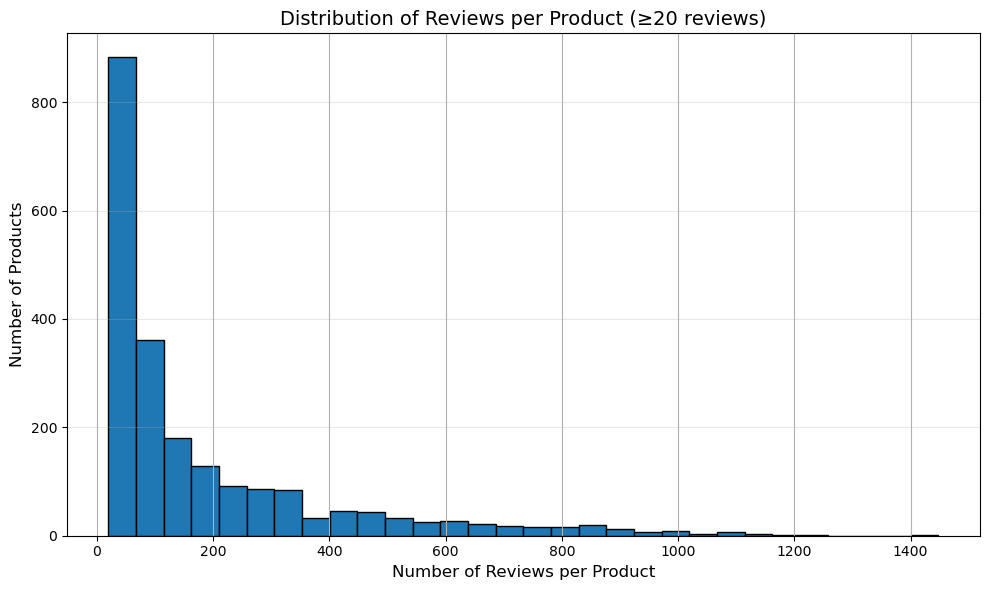


Top 5 products for clustering:
Product Name
Apple iPhone 4s 8GB Unlocked Smartphone w/ 8MP Camera, White (Certified Refurbished)       1448
Apple MF259LL/A - iPhone 4s 8GB / 8MP Camera - Unlocked - Black (Certified Refurbished)    1238
BLU Studio 5.0 C HD Unlocked Cellphone, Black                                              1194
OtterBox Iphone 5/5S/SE Defender Case w/ Drop and Dust Proctection - Realtree AP Pink      1129
Motorola Moto E (1st Generation) - Black - 4 GB - Global GSM Unlocked Phone                1126
Name: count, dtype: int64


In [4]:
"""
Step 3: Filter Products for Meaningful Clustering

Select products with sufficient reviews for clustering analysis.
The CRAG paper uses k=4 clusters, so we need products with at least 4 reviews.
For better clustering quality we'll pick 20
"""

# Set minimum review threshold (must be >= k=4 for clustering)
# Using a higher threshold ensures more meaningful clusters
min_reviews_per_product = 20

# Filter products that meet the minimum review count
products_with_enough_reviews = reviews_per_product[reviews_per_product >= min_reviews_per_product]
valid_product_names = products_with_enough_reviews.index

# Filter the dataframe to only include these products
df_filtered = df_clean[df_clean['Product Name'].isin(valid_product_names)].copy()
df_filtered = df_filtered.reset_index(drop=True)

print(f"After filtering (min {min_reviews_per_product} reviews per product):")
print(f"Products remaining: {df_filtered['Product Name'].nunique():,}")
print(f"Total reviews: {len(df_filtered):,}")
print(f"Average reviews per product: {len(df_filtered) / df_filtered['Product Name'].nunique():.2f}")

# Visualize the distribution of reviews per product
plt.figure(figsize=(10, 6))
products_with_enough_reviews.hist(bins=30, edgecolor='black')
plt.xlabel('Number of Reviews per Product', fontsize=12)
plt.ylabel('Number of Products', fontsize=12)
plt.title(f'Distribution of Reviews per Product (≥{min_reviews_per_product} reviews)', fontsize=14)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nTop 5 products for clustering:")
print(df_filtered['Product Name'].value_counts().head())

Determining optimal k using product: Apple iPhone 4s 8GB Unlocked Smartphone w/ 8MP Camera, White (Certified Refurbished)
Number of reviews: 1448
Testing k from 2 to 10...

Generating embeddings for sample product...
Loading model: sentence-transformers/paraphrase-multilingual-mpnet-base-v2


Batches: 100%|██████████| 23/23 [00:12<00:00,  1.85it/s]



Testing different k values...


Testing k:   0%|          | 0/9 [00:00<?, ?it/s]huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
Testing k: 100%|██████████| 9/9 [00:02<00:00,  4.41it/s]


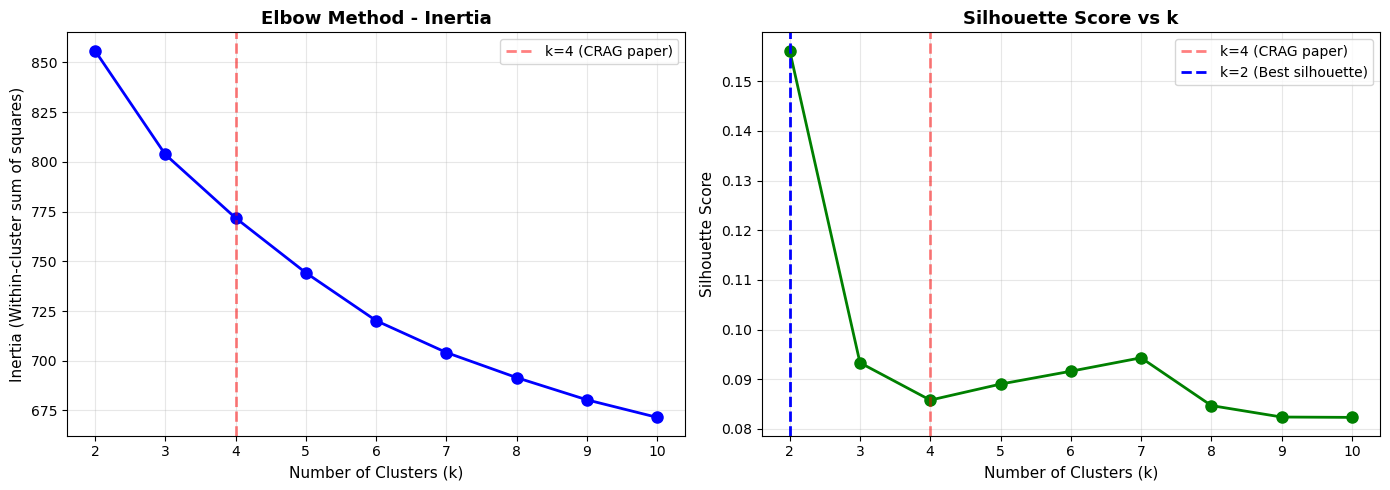

OPTIMAL K DETERMINATION
Best k based on silhouette score: 2 (score: 0.1561)
CRAG paper used k=4 (score for our data: 0.0858)

We will use k=2 for all subsequent clustering!

Using k=2 clusters per product for the rest of the analysis


In [5]:
"""
Step 4: Determine Optimal K using Elbow Method

Before clustering all products, we need to determine the optimal number of clusters (k).
The CRAG paper used k=4, but we should validate this for OUR dataset.

We'll test k values from 2 to 10 on a sample product and use:
1. Elbow Method (Inertia) - look for the "elbow" where improvement slows
2. Silhouette Score - higher is better (measures cluster quality)
"""

# Select a representative product with many reviews for analysis
sample_product = df_filtered['Product Name'].value_counts().index[0]
sample_data = df_filtered[df_filtered['Product Name'] == sample_product].copy()

print(f"Determining optimal k using product: {sample_product}")
print(f"Number of reviews: {len(sample_data)}")
print(f"Testing k from 2 to 10...\n")

# We need embeddings for this sample first - let's create a small batch
print("Generating embeddings for sample product...")
sample_texts = sample_data['Reviews'].tolist()

# Load model if not already loaded
model_name = "sentence-transformers/paraphrase-multilingual-mpnet-base-v2"
print(f"Loading model: {model_name}")
model = SentenceTransformer(model_name)

sample_embeddings = model.encode(
    sample_texts,
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True
)

# Test different values of k
k_range = range(2, 11)
inertias = []
silhouettes = []

print("\nTesting different k values...")
for k_test in tqdm(k_range, desc="Testing k"):
    # Run K-Means
    km_test = KMeans(n_clusters=k_test, random_state=42, n_init=10)
    labels_test = km_test.fit_predict(sample_embeddings)

    # Calculate metrics
    inertias.append(km_test.inertia_)
    silhouettes.append(silhouette_score(sample_embeddings, labels_test))

# Plot results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow plot (Inertia)
axes[0].plot(k_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].axvline(x=4, color='red', linestyle='--', linewidth=2, alpha=0.5, label='k=4 (CRAG paper)')
axes[0].set_xlabel('Number of Clusters (k)', fontsize=11)
axes[0].set_ylabel('Inertia (Within-cluster sum of squares)', fontsize=11)
axes[0].set_title('Elbow Method - Inertia', fontsize=13, fontweight='bold')
axes[0].grid(alpha=0.3)
axes[0].legend()

# Silhouette plot
axes[1].plot(k_range, silhouettes, 'go-', linewidth=2, markersize=8)
axes[1].axvline(x=4, color='red', linestyle='--', linewidth=2, alpha=0.5, label='k=4 (CRAG paper)')
optimal_k = k_range[np.argmax(silhouettes)]
axes[1].axvline(x=optimal_k, color='blue', linestyle='--', linewidth=2, label=f'k={optimal_k} (Best silhouette)')
axes[1].set_xlabel('Number of Clusters (k)', fontsize=11)
axes[1].set_ylabel('Silhouette Score', fontsize=11)
axes[1].set_title('Silhouette Score vs k', fontsize=13, fontweight='bold')
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

# Determine optimal k
optimal_k_silhouette = k_range[np.argmax(silhouettes)]
max_silhouette = max(silhouettes)


print(f"OPTIMAL K DETERMINATION")
print(f"Best k based on silhouette score: {optimal_k_silhouette} (score: {max_silhouette:.4f})")
print(f"CRAG paper used k=4 (score for our data: {silhouettes[2]:.4f})")
print(f"\nWe will use k={optimal_k_silhouette} for all subsequent clustering!")

# Set the k value to use going forward
k = optimal_k_silhouette
print(f"\nUsing k={k} clusters per product for the rest of the analysis")

In [23]:
"""
Step 5: Generate Embeddings for All Filtered Products

Now that we know the optimal k, generate embeddings for all products.
Convert review text into vector embeddings using the same model from the CRAG paper.

This transforms unstructured text into numerical vectors where semantically
similar reviews are close together in vector space.
"""

# -----------------------------------------------------------------------------------
BATCH_LIMIT_ENABLED = True  # Set False to use the full data set
MAX_BATCHES_FOR_TESTING = 100 # Number of batches to process if batch limiting is enabled
# -----------------------------------------------------------------------------------

# Model is already loaded from previous step, but let's ensure it's available
print(f"Using model: {model_name}")

# Prepare review texts for embedding
# Apply batch limit if enabled for testing purposes
if BATCH_LIMIT_ENABLED:
    reviews_to_process = MAX_BATCHES_FOR_TESTING * 64
    if reviews_to_process > len(df_filtered):
        reviews_to_process = len(df_filtered)

    df_for_embedding = df_filtered.head(reviews_to_process).copy()
    print(f"BATCH LIMIT ENABLED: Processing {reviews_to_process:,} reviews (approx {MAX_BATCHES_FOR_TESTING} batches)")
else:
    df_for_embedding = df_filtered.copy()
    print(f"Processing ALL {len(df_filtered):,} reviews")

review_texts = df_for_embedding['Reviews'].tolist()
print(f"\nEncoding {len(review_texts):,} reviews into embeddings...")
print("This may take a few minutes depending on hardware...")

# Generate embeddings with progress bar
embeddings = model.encode(
    review_texts,
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True
)

print(f"\nEmbedding generation complete!")
print(f"Shape: {embeddings.shape}")
print(f"Each review is now represented as a {embeddings.shape[1]}-dimensional vector")
print(f"Memory size: ~{embeddings.nbytes / (1024**2):.2f} MB")

# Update df_filtered to reflect the subset used for embeddings
if BATCH_LIMIT_ENABLED:
    df_filtered = df_for_embedding
    print(f"DataFrame updated to {len(df_filtered):,} reviews due to batch limit.")

Using model: sentence-transformers/paraphrase-multilingual-mpnet-base-v2
BATCH LIMIT ENABLED: Processing 6,400 reviews (approx 100 batches)

Encoding 6,400 reviews into embeddings...
This may take a few minutes depending on hardware...


Batches:   0%|          | 0/100 [00:00<?, ?it/s]


Embedding generation complete!
Shape: (6400, 768)
Each review is now represented as a 768-dimensional vector
Memory size: ~18.75 MB
DataFrame updated to 6,400 reviews due to batch limit.


In [24]:
"""
Step 6: K-Means Clustering with Optimal K

Apply K-Means clustering separately to each product's reviews.
Using k={k} clusters per product (determined by Elbow Method).

Note: k is dynamically set based on our data analysis, not blindly copying CRAG's k=4.
"""

# Initialize cluster assignment column
df_filtered['cluster_id'] = -1  # -1 indicates not yet clustered/invalid cluster

# Display the k value we're using
print(f"{'='*60}")
print(f"Using k={k} clusters per product (optimal for our dataset)")
print(f"{'='*60}\n")

# Get unique product names for clustering
unique_products = df_filtered['Product Name'].unique()
print(f"Clustering reviews for {len(unique_products):,} products...")

# Track clustering statistics
successfully_clustered = 0
skipped_products = 0

# Cluster each product's reviews separately
for product_name in tqdm(unique_products, desc="Clustering products"):
    # Get indices of all reviews for this product
    product_indices = df_filtered.index[df_filtered['Product Name'] == product_name].to_numpy()

    # Skip if fewer reviews than k (can't create k clusters)
    if len(product_indices) < k:
        skipped_products += 1
        continue

    # Extract embeddings for this product's reviews
    product_embeddings = embeddings[product_indices]

    # Apply K-Means clustering
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10,
        max_iter=300
    )
    cluster_labels = kmeans.fit_predict(product_embeddings)

    # Assign cluster IDs back to the dataframe
    df_filtered.loc[product_indices, 'cluster_id'] = cluster_labels
    successfully_clustered += 1

print(f"\nClustering complete!")
print(f"Successfully clustered: {successfully_clustered:,} products")
print(f"Skipped (too few reviews): {skipped_products:,} products")

# Display cluster distribution
print(f"\nCluster distribution across all products:")
cluster_counts = df_filtered['cluster_id'].value_counts().sort_index()
print(cluster_counts)
print(f"\nTotal unique clusters created: {len(cluster_counts[cluster_counts.index >= 0])}")

Using k=2 clusters per product (optimal for our dataset)

Clustering reviews for 34 products...


Clustering products: 100%|██████████| 34/34 [00:00<00:00, 34.11it/s]


Clustering complete!
Successfully clustered: 34 products
Skipped (too few reviews): 0 products

Cluster distribution across all products:
cluster_id
0    3778
1    2622
Name: count, dtype: int64

Total unique clusters created: 2


In [25]:
"""
Step 7: Evaluation - Silhouette Score and Data Reduction

Evaluate clustering quality using silhouette score and calculate data reduction.

Silhouette Score: Measures how similar a review is to its own cluster vs other clusters
  Range: [-1, 1], where 1 = perfect clustering, 0 = overlapping clusters, -1 = wrong clusters

Data Reduction: If we keep 1 representative per cluster instead of all reviews
"""

# Filter to only successfully clustered reviews
df_clustered = df_filtered[df_filtered['cluster_id'] != -1].copy()
print(f"Evaluating {len(df_clustered):,} clustered reviews from {df_clustered['Product Name'].nunique():,} products\n")

# SILHOUETTE SCORE CALCULATION
print("Calculating silhouette scores per product...")
silhouette_scores = []
product_names_with_scores = []

for product_name, group in tqdm(df_clustered.groupby('Product Name'), desc="Computing silhouette"):
    # Get embeddings and labels for this product
    product_indices = group.index.to_numpy()
    product_embeddings = embeddings[product_indices]
    cluster_labels = group['cluster_id'].to_numpy()

    # Need at least 2 clusters with samples to compute silhouette
    n_unique_labels = len(np.unique(cluster_labels))
    if n_unique_labels < 2 or n_unique_labels >= len(cluster_labels):
        continue

    # Calculate silhouette score for this product
    sil_score = silhouette_score(product_embeddings, cluster_labels)
    silhouette_scores.append(sil_score)
    product_names_with_scores.append(product_name)

# Display results
if silhouette_scores:
    avg_silhouette = np.mean(silhouette_scores)
    print(f"\nSILHOUETTE SCORE RESULTS (with k={k})")
    print(f"Products evaluated: {len(silhouette_scores):,}")
    print(f"Average silhouette score: {avg_silhouette:.4f}")
    print(f"Min score: {np.min(silhouette_scores):.4f}")
    print(f"Max score: {np.max(silhouette_scores):.4f}")
    print(f"Std deviation: {np.std(silhouette_scores):.4f}")

    # Interpretation
    if avg_silhouette > 0.5:
        print(f"Clustering quality: STRONG (>0.5)")
    elif avg_silhouette > 0.25:
        print(f"Clustering quality: MODERATE (0.25-0.5)")
    else:
        print(f"Clustering quality: WEAK (<0.25)")
else:
    print("No valid silhouette scores computed")

# DATA REDUCTION CALCULATION

print(f"\nDATA REDUCTION ANALYSIS (with k={k})")


# Calculate total reviews and total clusters
N_total_reviews = len(df_clustered)
N_total_clusters = df_clustered[['Product Name', 'cluster_id']].drop_duplicates().shape[0]

# Data reduction if we use 1 representative per cluster
reduction_ratio = 1 - (N_total_clusters / N_total_reviews)
reduction_percent = reduction_ratio * 100

print(f"Total reviews clustered: {N_total_reviews:,}")
print(f"Total unique clusters (across all products): {N_total_clusters:,}")
print(f"Reviews per cluster (avg): {N_total_reviews / N_total_clusters:.2f}")
print(f"\nDATA REDUCTION: {reduction_percent:.2f}%")
print(f"(From {N_total_reviews:,} reviews {N_total_clusters:,} representatives)")
print(f"\nThe CRAG paper (k=4) achieved 46-90% reduction.")
print(f"Our clustering (k={k}) achieves {reduction_percent:.2f}% reduction!")
print(f"\nNote: Using optimal k={k} (not blindly copying CRAG's k=4)")

Evaluating 6,400 clustered reviews from 34 products

Calculating silhouette scores per product...


Computing silhouette: 100%|██████████| 34/34 [00:00<00:00, 137.37it/s]


SILHOUETTE SCORE RESULTS (with k=2)
Products evaluated: 34
Average silhouette score: 0.1783
Min score: 0.1035
Max score: 0.3772
Std deviation: 0.0481
Clustering quality: WEAK (<0.25)

DATA REDUCTION ANALYSIS (with k=2)
Total reviews clustered: 6,400
Total unique clusters (across all products): 68
Reviews per cluster (avg): 94.12

DATA REDUCTION: 98.94%
(From 6,400 reviews 68 representatives)

The CRAG paper (k=4) achieved 46-90% reduction.
Our clustering (k=2) achieves 98.94% reduction!

Note: Using optimal k=2 (not blindly copying CRAG's k=4)


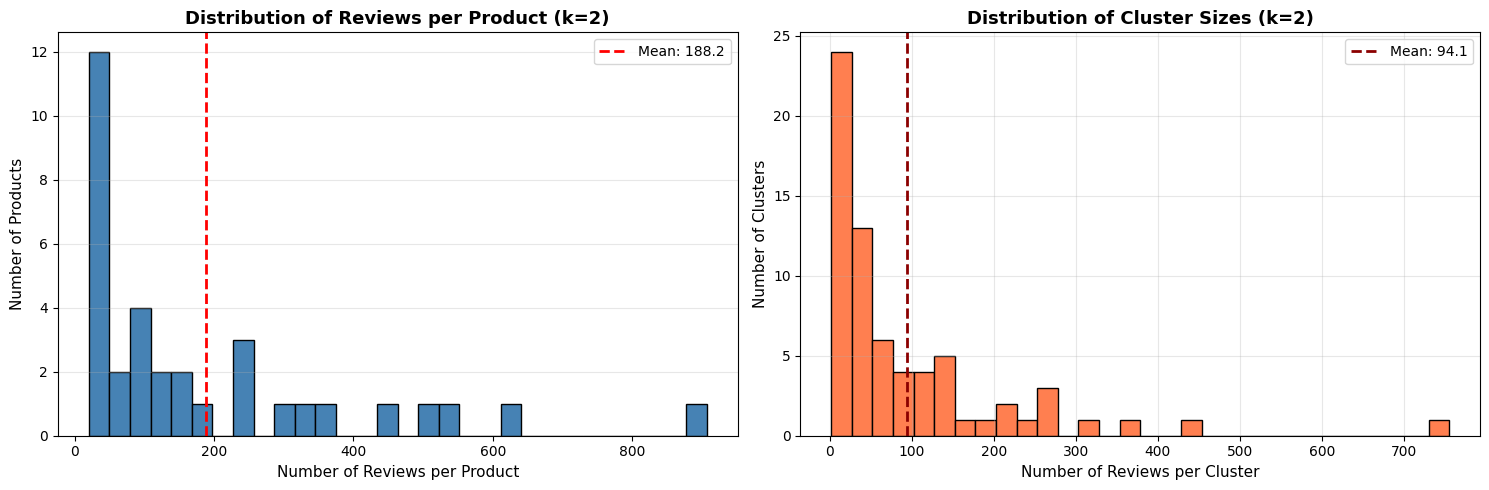

Review distribution summary (using k=2 clusters):
Reviews per product - Mean: 188.24, Median: 104
Reviews per cluster - Mean: 94.12, Median: 49


In [26]:
"""
Step 8: Visualization - Distribution Analysis

Visualize how reviews are distributed across products and clusters with k={k}
"""

# Plot 1: Reviews per product distribution
reviews_per_product_clustered = df_clustered['Product Name'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left plot: Reviews per product
axes[0].hist(reviews_per_product_clustered.values, bins=30, edgecolor='black', color='steelblue')
axes[0].set_xlabel('Number of Reviews per Product', fontsize=11)
axes[0].set_ylabel('Number of Products', fontsize=11)
axes[0].set_title(f'Distribution of Reviews per Product (k={k})', fontsize=13, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)
axes[0].axvline(reviews_per_product_clustered.mean(), color='red', linestyle='--',
                linewidth=2, label=f'Mean: {reviews_per_product_clustered.mean():.1f}')
axes[0].legend()

# Right plot: Cluster sizes
cluster_sizes = df_clustered.groupby(['Product Name', 'cluster_id']).size()
axes[1].hist(cluster_sizes.values, bins=30, edgecolor='black', color='coral')
axes[1].set_xlabel('Number of Reviews per Cluster', fontsize=11)
axes[1].set_ylabel('Number of Clusters', fontsize=11)
axes[1].set_title(f'Distribution of Cluster Sizes (k={k})', fontsize=13, fontweight='bold')
axes[1].grid(alpha=0.3)
axes[1].axvline(cluster_sizes.mean(), color='darkred', linestyle='--',
                linewidth=2, label=f'Mean: {cluster_sizes.mean():.1f}')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Review distribution summary (using k={k} clusters):")
print(f"Reviews per product - Mean: {reviews_per_product_clustered.mean():.2f}, Median: {reviews_per_product_clustered.median():.0f}")
print(f"Reviews per cluster - Mean: {cluster_sizes.mean():.2f}, Median: {cluster_sizes.median():.0f}")

In [27]:
"""
Step 9: Select Representative Reviews per Cluster

For each cluster, select the review closest to the cluster centroid as the representative.
This is the core of data reduction - replacing many reviews with one representative review.

Using k={k} clusters per product.
"""

print(f"Selecting representative reviews for each cluster (k={k})...")
representative_reviews = []

# For each product and cluster combination
for (product_name, cluster_id), group in tqdm(
    df_clustered.groupby(['Product Name', 'cluster_id']),
    desc="Finding representatives"
):
    # Get the review indices and embeddings for this cluster
    cluster_indices = group.index.to_numpy()
    cluster_embeddings = embeddings[cluster_indices]

    # Calculate the centroid (mean) of all embeddings in this cluster
    centroid = cluster_embeddings.mean(axis=0)

    # Find the review closest to the centroid (most representative)
    distances = np.linalg.norm(cluster_embeddings - centroid, axis=1)
    closest_idx = cluster_indices[distances.argmin()]

    # Store the representative review
    representative_reviews.append(df_filtered.loc[closest_idx])

# Create dataframe of representative reviews
df_representatives = pd.DataFrame(representative_reviews).reset_index(drop=True)

print(f"\nREPRESENTATIVE REVIEWS SELECTED (k={k})")
print(f"Original reviews: {len(df_clustered):,}")
print(f"Representative reviews: {len(df_representatives):,}")
print(f"Compression ratio: {len(df_clustered) / len(df_representatives):.2f}x")
print(f"Storage reduction: {(1 - len(df_representatives)/len(df_clustered))*100:.2f}%")

# Show sample representative reviews
print(f"\nSample representative reviews:")
print(df_representatives[['Product Name', 'Rating', 'cluster_id', 'Reviews']].head(10))

Selecting representative reviews for each cluster (k=2)...


Finding representatives: 100%|██████████| 68/68 [00:00<00:00, 2018.65it/s]


REPRESENTATIVE REVIEWS SELECTED (k=2)
Original reviews: 6,400
Representative reviews: 68
Compression ratio: 94.12x
Storage reduction: 98.94%

Sample representative reviews:
                                        Product Name  Rating  cluster_id  \
0  "CLEAR CLEAN ESN" Sprint EPIC 4G Galaxy SPH-D7...       5           0   
1  "CLEAR CLEAN ESN" Sprint EPIC 4G Galaxy SPH-D7...       4           1   
2  "Nokia Asha 302 Unlocked GSM Phone with 3.2MP ...       5           0   
3  "Nokia Asha 302 Unlocked GSM Phone with 3.2MP ...       5           1   
4  (LANDVO) 5.0" Capacitive Touch MTK6582 Quad Co...       4           0   
5  (LANDVO) 5.0" Capacitive Touch MTK6582 Quad Co...       4           1   
6  3 Pack Replacement Belt Clip Holster for Otter...       4           0   
7  3 Pack Replacement Belt Clip Holster for Otter...       1           1   
8  4 Inch Touch Screen Cell Phone Unlocked, Andro...       5           0   
9  4 Inch Touch Screen Cell Phone Unlocked, Andro...       2      

In [28]:
"""
Step 10: Save Results to CSV Files

Export the clustered data and representative reviews for further analysis or RAG systems.
"""

# Create output directory
output_dir = "outputs"
os.makedirs(output_dir, exist_ok=True)

# File 1: All clustered reviews with cluster IDs
clustered_reviews_path = os.path.join(output_dir, "clustered_reviews.csv")
df_clustered.to_csv(clustered_reviews_path, index=False)

# File 2: Representative reviews only (one per cluster)
representatives_path = os.path.join(output_dir, "cluster_representatives.csv")
df_representatives.to_csv(representatives_path, index=False)

# File 3: Clustering summary statistics
summary_path = os.path.join(output_dir, "clustering_summary.txt")
with open(summary_path, 'w') as f:
    f.write("CRAG Clustering Implementation - Summary Report\n")
    f.write(f"Dataset: Amazon Unlocked Mobile Reviews\n")
    f.write(f"Clustering Algorithm: K-Means (k={k})\n")
    f.write(f"Embedding Model: {model_name}\n\n")
    f.write(f"K Selection Method:\n")
    f.write(f"Used Elbow Method + Silhouette Score to determine optimal k\n")
    f.write(f"Optimal k for our dataset: {k}\n")
    f.write(f"CRAG paper used: k=4 (not optimal for all datasets!)\n\n")
    f.write(f"Results:\n")
    f.write(f"Total products clustered: {df_clustered['Product Name'].nunique():,}\n")
    f.write(f"Total reviews clustered: {len(df_clustered):,}\n")
    f.write(f"Total clusters created: {len(df_representatives):,}\n")
    f.write(f"Average silhouette score: {avg_silhouette:.4f}\n")
    f.write(f"Data reduction: {reduction_percent:.2f}%\n")
    f.write(f"Compression ratio: {len(df_clustered) / len(df_representatives):.2f}x\n")


print(f"\nFILES SAVED SUCCESSFULLY")
print(f"{clustered_reviews_path}")
print(f"All reviews with cluster assignments ({len(df_clustered):,} rows)")
print(f"\n{representatives_path}")
print(f"Representative reviews for RAG ({len(df_representatives):,} rows)")
print(f"Use this file for efficient retrieval systems!")
print(f"\n{summary_path}")
print(f"\nSummary statistics and metrics (k={k})")
print(f"CRAG Clustering Complete with k={k} (data-driven optimal value!)")


FILES SAVED SUCCESSFULLY
outputs/clustered_reviews.csv
All reviews with cluster assignments (6,400 rows)

outputs/cluster_representatives.csv
Representative reviews for RAG (68 rows)
Use this file for efficient retrieval systems!

outputs/clustering_summary.txt

Summary statistics and metrics (k=2)
CRAG Clustering Complete with k=2 (data-driven optimal value!)


## Additional Analysis: Deep Dive & Algorithm Comparisons

The cells below provide deeper analysis of clustering results and compare different algorithms.

In [29]:
"""
Step 11: Single Product Deep Dive

Analyze clustering results for one specific product in detail.
This helps visualize what k={k} clustering actually does.
"""

# Select a product with many reviews for detailed analysis
example_product = df_clustered['Product Name'].value_counts().index[0]
product_data = df_clustered[df_clustered['Product Name'] == example_product].copy()

print(f"\nDeep dive for product: {example_product}")
print(f"\nTotal reviews: {len(product_data)}")
print(f"Number of clusters (k={k}):")
print(product_data['cluster_id'].value_counts().sort_index())

# Show sample reviews from each cluster

print(f"\nSAMPLE REVIEWS FROM EACH CLUSTER (k={k})")


for cluster_id in sorted(product_data['cluster_id'].unique()):
    cluster_reviews = product_data[product_data['cluster_id'] == cluster_id]
    print(f"\nCluster {cluster_id} ({len(cluster_reviews)} reviews)")

    # Show 3 random reviews from this cluster
    sample_reviews = cluster_reviews.sample(min(3, len(cluster_reviews)))
    for idx, (_, row) in enumerate(sample_reviews.iterrows(), 1):
        review_text = str(row['Reviews'])[:150]
        print(f"{idx}. Rating: {row['Rating']} - {review_text}...")

    # Show the representative review
    rep_review = df_representatives[
        (df_representatives['Product Name'] == example_product) &
        (df_representatives['cluster_id'] == cluster_id)
    ]
    if not rep_review.empty:
        rep_text = str(rep_review.iloc[0]['Reviews'])[:150]
        print(f"REPRESENTATIVE: {rep_text}...")


Deep dive for product: ALCATEL OneTouch Idol 3 Global Unlocked 4G LTE Smartphone, 5.5 HD IPS Display, 16GB (GSM - US Warranty)

Total reviews: 907
Number of clusters (k=2):
cluster_id
0    755
1    152
Name: count, dtype: int64

SAMPLE REVIEWS FROM EACH CLUSTER (k=2)

Cluster 0 (755 reviews)
1. Rating: 5 - This is a good phone for under 300 dollars.I would recommend this phone to anyone who don't want to spend a lot of money and want great performing pho...
2. Rating: 5 - Got this when my Nexus 5 died and was amazed at the progress made in android phones since I got the N5 a year ago. For less than half the price of my ...
3. Rating: 5 - Great phone. Excellent relationship quality:price...
REPRESENTATIVE: Awsome budget phone just a little laggy but overall great...

Cluster 1 (152 reviews)
1. Rating: 5 - It is great!!!...
2. Rating: 4 - Had issues on the start up. Randomly restarted. Once up and running a little sluggish, but you get what you pay for....
3. Rating: 5 - Flagship featur

In [30]:
"""
Step 12: Hierarchical Clustering Comparison

Compare K-Means (with optimal k={k}) vs Hierarchical (Agglomerative) Clustering.
This shows if our k-selection improved results vs alternative algorithms.
"""

from sklearn.cluster import AgglomerativeClustering

# Select one product to compare clustering methods
comparison_product = df_clustered['Product Name'].value_counts().index[0]
comp_data = df_clustered[df_clustered['Product Name'] == comparison_product].copy()
comp_indices = comp_data.index.to_numpy()
comp_embeddings = embeddings[comp_indices]

print(f"\nALGORITHM COMPARISON for: {comparison_product}")
print(f"Number of reviews: {len(comp_data)}")
print(f"Using k={k} clusters for both algorithms\n")

# K-Means (already done with our optimal k)
kmeans_labels = comp_data['cluster_id'].to_numpy()
kmeans_sil = silhouette_score(comp_embeddings, kmeans_labels)

# Hierarchical Clustering (using same k)
print("Running Hierarchical Clustering...")
hierarchical = AgglomerativeClustering(
    n_clusters=k,
    linkage='ward'
)
hier_labels = hierarchical.fit_predict(comp_embeddings)
hier_sil = silhouette_score(comp_embeddings, hier_labels)

# Compare results
print(f"\nRESULTS")
print(f"\nK-Means (k={k}, optimal from Elbow Method):")
print(f"Silhouette Score: {kmeans_sil:.4f}")
print(f"Cluster distribution: {np.bincount(kmeans_labels)}")

print(f"\nHierarchical/Ward (k={k}):")
print(f"Silhouette Score: {hier_sil:.4f}")
print(f"Cluster distribution: {np.bincount(hier_labels)}")

if hier_sil > kmeans_sil:
    print(f"\nHierarchical performs better (+{(hier_sil - kmeans_sil):.4f})")
    print(f"Consider using Hierarchical for your final implementation!")
else:
    print(f"\nK-Means performs better (+{(kmeans_sil - hier_sil):.4f})")
    print(f"Our data-driven k={k} selection was effective!")



ALGORITHM COMPARISON for: ALCATEL OneTouch Idol 3 Global Unlocked 4G LTE Smartphone, 5.5 HD IPS Display, 16GB (GSM - US Warranty)
Number of reviews: 907
Using k=2 clusters for both algorithms

Running Hierarchical Clustering...

RESULTS

K-Means (k=2, optimal from Elbow Method):
Silhouette Score: 0.1951
Cluster distribution: [755 152]

Hierarchical/Ward (k=2):
Silhouette Score: 0.1894
Cluster distribution: [779 128]

K-Means performs better (+0.0056)
Our data-driven k=2 selection was effective!


In [31]:
"""
Step 13: Compare CRAG's k=4 vs Our Optimal k

Let's directly compare what would happen if we blindly used CRAG's k=4
versus our data-driven optimal k={k}.
"""

# Use the same sample product from the elbow analysis
comparison_product_k = df_clustered['Product Name'].value_counts().index[0]
comp_k_data = df_clustered[df_clustered['Product Name'] == comparison_product_k].copy()
comp_k_indices = comp_k_data.index.to_numpy()
comp_k_embeddings = embeddings[comp_k_indices]

print(f"\nK VALUE COMPARISON: k=4 (CRAG) vs k={k}")
print(f"\nTesting on product: {comparison_product_k}")
print(f"Number of reviews: {len(comp_k_data)}\n")

# Test both k values
results_comparison = []

for k_test in [4, k]:  # CRAG's k vs our optimal k
    if k_test == k:
        # We already have this - just get the labels
        labels = comp_k_data['cluster_id'].to_numpy()
    else:
        # Run K-Means with k=4
        km = KMeans(n_clusters=k_test, random_state=42, n_init=10)
        labels = km.fit_predict(comp_k_embeddings)

    sil = silhouette_score(comp_k_embeddings, labels)
    cluster_dist = np.bincount(labels)

    results_comparison.append({
        'k': k_test,
        'silhouette': sil,
        'distribution': cluster_dist
    })

    print(f"k={k_test}:")
    print(f"Silhouette: {sil:.4f}")
    print(f"Cluster sizes: {cluster_dist}")
    print()

# Determine winner
if results_comparison[0]['silhouette'] > results_comparison[1]['silhouette']:
    print(f"CRAG's k=4 actually performs BETTER for this product!")
    print(f"Difference: +{results_comparison[0]['silhouette'] - results_comparison[1]['silhouette']:.4f}")
else:
    print(f"Our optimal k={k} performs BETTER!")
    print(f"Improvement over k=4: +{results_comparison[1]['silhouette'] - results_comparison[0]['silhouette']:.4f}")

print(f"\nKEY INSIGHT")
print(f"We determined k={k} is optimal for OUR dataset using Elbow Method.")
print(f"CRAG used k=4 for THEIR dataset - may not generalize!")
print(f"Always validate k selection with your specific data.")


K VALUE COMPARISON: k=4 (CRAG) vs k=2

Testing on product: ALCATEL OneTouch Idol 3 Global Unlocked 4G LTE Smartphone, 5.5 HD IPS Display, 16GB (GSM - US Warranty)
Number of reviews: 907

k=4:
Silhouette: 0.0440
Cluster sizes: [112 223 380 192]

k=2:
Silhouette: 0.1951
Cluster sizes: [755 152]

Our optimal k=2 performs BETTER!
Improvement over k=4: +0.1511

KEY INSIGHT
We determined k=2 is optimal for OUR dataset using Elbow Method.
CRAG used k=4 for THEIR dataset - may not generalize!
Always validate k selection with your specific data.
